# Introduction to Optimization

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture **introduction to optimization**
(Week 1 — Derivatives and Optimization).

This notebook explains:

- why derivatives matter in machine learning: **optimization** (finding maxima/minima)
- the 1D **sauna-bench** intuition for moving toward the coldest spot
- how the **sign of the slope** points toward lower values, and the minimum has **slope 0**
- **candidates** for max/min = points where the derivative is zero; **local vs global** minima

This notebook follows the repository `GUIDELINES.md` template and connects the Week 1
derivative tools to the optimization that follows.

## 1. Why derivatives? Optimization

Beyond measuring rates of change, derivatives are used for **optimization** — finding the
**maximum** or **minimum** of a function.

This is central to machine learning: you fit the best model to data by defining an **error
(loss) function** that measures how far the model is from ideal, then **minimizing** it. The
minimum gives the best model.

## 2. The sauna bench

You're on a sauna bench and it's too hot, so you look for the **coldest spot**. With a
thermometer reading $85^\circ$C:

- move **left** → $90^\circ$C (hotter — wrong way),
- move **right** → $80^\circ$C (colder — good),
- keep moving right, recording lower temperatures,
- stop when **any** direction gets hotter — that's the coldest spot.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# a temperature-along-the-bench curve with a single coldest point
def temp(x):
    return 0.5*(x - 3)**2 + 75      # minimum 75 at x = 3

# the search: start, a bad step, then steps toward colder
print(f"start  (x=1.0): {temp(1.0):.0f}°C")
print(f"left   (x=0.5): {temp(0.5):.0f}°C  (hotter)")
print(f"right  (x=1.5): {temp(1.5):.0f}°C  (colder -> keep going right)")
print(f"...    (x=2.5): {temp(2.5):.0f}°C")
print(f"coldest(x=3.0): {temp(3.0):.0f}°C  (any move now gets hotter)")

start  (x=1.0): 77°C
left   (x=0.5): 78°C  (hotter)
right  (x=1.5): 76°C  (colder -> keep going right)
...    (x=2.5): 75°C
coldest(x=3.0): 75°C  (any move now gets hotter)


## 3. The slope points the way

Look at the tangent slope along the curve:

- where moving **right** leads to colder → slope is **negative** ($f' < 0$),
- where moving **left** leads to colder → slope is **positive** ($f' > 0$),
- at the **coldest** point (any direction is hotter) → slope is **zero** ($f' = 0$).

> *"At maximum and minimum points, the slope is always zero."*

In [2]:
x = sp.symbols('x')
T = sp.Rational(1,2)*(x - 3)**2 + 75
Tp = sp.diff(T, x)
print("T'(x) =", Tp)
for xv in [1.0, 2.0, 3.0, 4.0]:
    s = float(Tp.subs(x, xv))
    where = "colder to the right" if s < 0 else "colder to the left" if s > 0 else "COLDEST (slope 0)"
    print(f"  at x={xv}: slope = {s:+.1f}  -> {where}")

print("\nminimum where T'(x)=0:", sp.solve(Tp, x))

T'(x) = x - 3
  at x=1.0: slope = -2.0  -> colder to the right
  at x=2.0: slope = -1.0  -> colder to the right
  at x=3.0: slope = +0.0  -> COLDEST (slope 0)
  at x=4.0: slope = +1.0  -> colder to the left

minimum where T'(x)=0: [3]


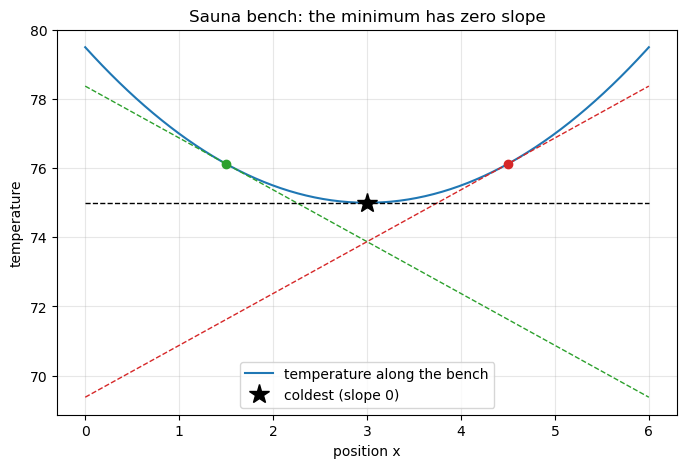

In [3]:
xs = np.linspace(0, 6, 200)
plt.figure(figsize=(8, 5))
plt.plot(xs, temp(xs), label="temperature along the bench")
# tangents at three points
for xv, col in [(1.5, "tab:green"), (4.5, "tab:red"), (3.0, "black")]:
    s = (xv - 3)
    plt.plot(xs, temp(xv) + s*(xs - xv), "--", color=col, lw=1)
    plt.plot(xv, temp(xv), "o", color=col)
plt.plot(3, temp(3), "k*", markersize=15, label="coldest (slope 0)")
plt.title("Sauna bench: the minimum has zero slope")
plt.xlabel("position x"); plt.ylabel("temperature")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. Zero slope ≠ always a minimum

A zero slope makes a point a **candidate**, but not every candidate is *the* minimum. In a
more complicated "sauna" there can be **several** points with zero derivative:

- each is a **local** minimum/maximum (best only in its neighborhood),
- the lowest overall is the **global** minimum.

You must check all the candidates to find the global one.

In [4]:
# a bumpy temperature curve with several zero-slope points
def bumpy(x):
    return np.sin(3*x) + 0.3*x**2 + 78

xb = sp.symbols('x')
Tb = sp.sin(3*xb) + sp.Rational(3,10)*xb**2 + 78
crit = sp.nsolve  # we'll scan numerically instead

# find zero-derivative points by sign changes of the numerical derivative
xs = np.linspace(-2.5, 2.5, 4000)
dT = np.gradient(bumpy(xs), xs)
cands = xs[1:][np.sign(dT[:-1]) != np.sign(dT[1:])]
print("candidate points (slope ~ 0):", np.round(cands, 3))

vals = bumpy(cands)
gmin = cands[np.argmin(vals)]
print(f"global minimum among candidates: x = {gmin:.3f}, T = {bumpy(gmin):.3f}")

candidate points (slope ~ 0): [-2.447 -1.685 -0.491  0.562  1.472]
global minimum among candidates: x = -0.491, T = 77.077


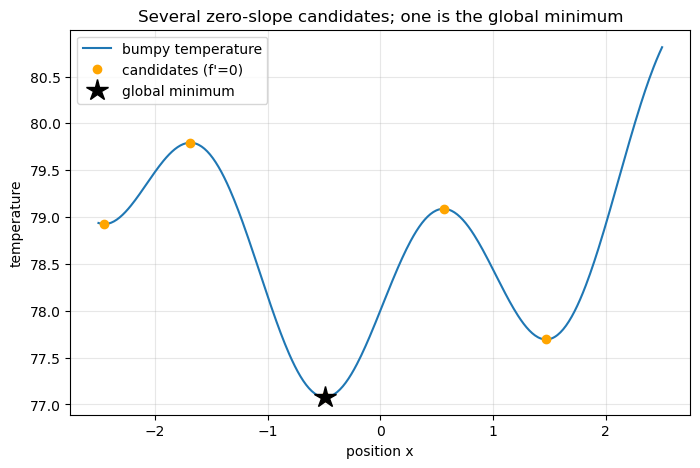

In [5]:
xs = np.linspace(-2.5, 2.5, 400)
plt.figure(figsize=(8, 5))
plt.plot(xs, bumpy(xs), label="bumpy temperature")
plt.plot(cands, bumpy(cands), "o", color="orange", label="candidates (f'=0)")
plt.plot(gmin, bumpy(gmin), "k*", markersize=16, label="global minimum")
plt.title("Several zero-slope candidates; one is the global minimum")
plt.xlabel("position x"); plt.ylabel("temperature")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 5. The principle

> *"If the function is differentiable at every point, the candidates for maximum and minimum
> are those points for which the derivative is zero."*

$$
\boxed{\text{candidates for max/min} \;\Longleftrightarrow\; f'(x) = 0.}
$$

- **Local minimum/maximum:** best in a neighborhood.
- **Global minimum/maximum:** best overall — found by comparing all candidates.

## 6. Exercises

### Basic
1. What is optimization, and why does machine learning need it?
2. What is the slope of the tangent at a maximum or minimum?

### Intermediate
3. For $f(x) = \tfrac12(x-3)^2 + 75$, find the point where $f'(x) = 0$.
4. If the slope at your position is negative, which way is "downhill"?

### Advanced
5. Find all candidate points (where $f'(x)=0$) of $f(x) = x^3 - 3x$ and classify which is a
   local min vs local max.
6. Explain the difference between a local minimum and the global minimum, and why $f'(x)=0$
   alone can't distinguish them.

## 7. Solutions / Checks

In [6]:
x = sp.symbols('x')

# 3.
T = sp.Rational(1,2)*(x-3)**2 + 75
print("3. f'(x)=0 at x =", sp.solve(sp.diff(T, x), x))

# 5.
f = x**3 - 3*x
crit = sp.solve(sp.diff(f, x), x)
print("5. candidates:", crit)
for c in crit:
    second = sp.diff(f, x, 2).subs(x, c)
    print(f"   x={c}: f''={second} -> {'local min' if second>0 else 'local max'}")

print("\n1. Finding a max/min; ML minimizes an error function to fit the best model.")
print("2. Zero.")
print("4. Negative slope -> downhill is to the right (move in +x).")
print("6. Local = best nearby; global = best overall. f'=0 marks all candidates but doesn't "
      "say which is lowest/highest.")

3. f'(x)=0 at x = [3]
5. candidates: [-1, 1]
   x=-1: f''=-6 -> local max
   x=1: f''=6 -> local min

1. Finding a max/min; ML minimizes an error function to fit the best model.
2. Zero.
4. Negative slope -> downhill is to the right (move in +x).
6. Local = best nearby; global = best overall. f'=0 marks all candidates but doesn't say which is lowest/highest.


## 8. Conclusion

- Derivatives power **optimization** — finding maxima/minima — which is how ML fits models by
  minimizing an error function.
- The **sign of the slope** points toward lower values; at a maximum or minimum the slope is
  **zero**.
- Points with $f'(x) = 0$ are **candidates**; comparing them separates **local** optima from
  the **global** optimum.
- Next, these ideas extend to many variables (gradients) and to iterative methods (gradient
  descent).

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (21).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **introduction to optimization**. Key spoken points, lightly
cleaned:

> Derivatives are useful in machine learning mainly for optimization — finding the maximum
> or minimum of a function — because you fit the best model by minimizing an error function
> that measures how far you are from ideal. Example: sitting in a sauna, too hot, you look
> for the coldest spot. The thermometer reads $85^\circ$; moving left gives $90^\circ$
> (hotter), moving right gives $80^\circ$ (colder), so you keep going right, recording lower
> temperatures until any direction gets hotter — that's the coldest spot. On the
> temperature curve, where moving right leads colder the slope is negative; where moving
> left leads colder the slope is positive; and at the coldest point the slope is zero —
> maxima and minima always have zero slope. But not every zero-slope point is a max or min:
> a complicated curve has several such points (candidates) — local minima — and the lowest
> is the global minimum. So for a differentiable function, the candidates for max/min are
> the points where the derivative is zero.